\# Running & Evaluating a Small Language Model
## Gemma 2 (2B) — Code Generation with HumanEval

**Course:** Introduction to Language Models
**Duration:** ~1 hour
**Platform:** Google Colab (free-tier T4 GPU)

---

### What you'll learn

1. How to load and run a small language model (Gemma 2 2B) on a free GPU
2. How text generation works — tokeniza

```
# Esto tiene formato de código
```

tion, decoding strategies, and sampling
3. How to evaluate a model's code generation ability using the **HumanEval** benchmark
4. The concepts of **pass@1** and **pass@k** metrics

### Why small language models?

Large language models (70B+ parameters) deliver impressive results but require expensive hardware. **Small language models** (1–3B parameters) are interesting because they:

- Run on consumer GPUs and even mobile devices
- Are cheaper to serve and faster at inference
- Allow experimentation without cloud budgets
- Reveal what capabilities emerge (or don't) at smaller scales

**Gemma 2 2B** is Google's open-weight model with 2.6 billion parameters — small enough for a free Colab GPU, yet capable enough to demonstrate real generation behavior.

---
## 1. Environment Setup

We'll install the Hugging Face ecosystem and authenticate to access Gemma 2 (which requires accepting Google's license terms).

> **Before running:** Make sure you've accepted the Gemma license at [huggingface.co/google/gemma-2-2b](https://huggingface.co/google/gemma-2-2b) and have a Hugging Face access token ready.

In [ ]:
# Install dependencies
!pip install -q transformers accelerate datasets torch

# Authenticate with Hugging Face (required for Gemma 2)
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# Verify GPU is available
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU available: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("⚠️ No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

✅ GPU available: Tesla T4 (15.6 GB)
PyTorch version: 2.10.0+cu128
Device: cuda


---
## 2. Loading Gemma 2 (2B)

We load the model and tokenizer from Hugging Face. Key things to notice:

- **AutoModelForCausalLM**: loads a model designed for *next-token prediction* (causal language modeling)
- **torch.float16**: half-precision to fit in GPU memory (~5 GB instead of ~10 GB)
- **device_map="auto"**: automatically places the model on the GPU

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "google/gemma-2-2b"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Loading model (this takes ~1-2 minutes)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"✅ Model loaded!")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading tokenizer...


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

✅ Model loaded!
   Parameters: 2,614,341,888
   Memory: 5.23 GB


### 🔍 Exercise: Explore the model

Run the cell below to inspect the model's configuration. Pay attention to:
- `hidden_size`: the dimension of the internal representations
- `num_hidden_layers`: how deep the model is
- `num_attention_heads`: how many parallel attention mechanisms per layer
- `vocab_size`: how many tokens the model knows

In [ ]:
# Inspect the model configuration
print(model.config)

Gemma2Config {
  "architectures": [
    "Gemma2ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": 50.0,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "float16",
  "eos_token_id": 1,
  "final_logit_softcapping": 30.0,
  "head_dim": 256,
  "hidden_act": "gelu_pytorch_tanh",
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 2304,
  "initializer_range": 0.02,
  "intermediate_size": 9216,
  "layer_types": [
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attent

---
## 3. Generating Text

Language models generate text **one token at a time**. At each step, the model outputs a probability distribution over its entire vocabulary, and a **decoding strategy** decides which token to pick next.

Let's explore the main strategies:

In [ ]:
def generate_text(prompt, max_new_tokens=150, **kwargs):
    """Helper function to generate text from a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            **kwargs
        )

    # Decode only the NEW tokens (skip the prompt)
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

### Decoding strategies compared

| Strategy | How it works | Tradeoff |
|---|---|---|
| **Greedy** | Always pick the most probable token | Deterministic but repetitive |
| **Top-k** | Sample from the top k most probable tokens | More diverse, k controls randomness |
| **Top-p (nucleus)** | Sample from the smallest set of tokens whose probabilities sum to p | Adaptive diversity |
| **Temperature** | Scale logits before sampling — low = confident, high = random | Controls "creativity" |

In [ ]:
prompt = "def fibonacci(n):\n    \"\"\"Return the n-th Fibonacci number.\"\"\"\n"

print("=" * 60)
print("GREEDY DECODING")
print("=" * 60)
print(generate_text(prompt, max_new_tokens=100, do_sample=False))

print("\n" + "=" * 60)
print("TOP-K SAMPLING (k=50, temp=0.7)")
print("=" * 60)
print(generate_text(prompt, max_new_tokens=100, do_sample=True, top_k=50, temperature=0.7))

print("\n" + "=" * 60)
print("TOP-P SAMPLING (p=0.9, temp=0.8)")
print("=" * 60)
print(generate_text(prompt, max_new_tokens=100, do_sample=True, top_p=0.9, temperature=0.8))

GREEDY DECODING
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)

def main():
    """Print the first 10 Fibonacci numbers."""
    for i in range(10):
        print(fibonacci(i))

if __name__ == '__main__':
    main()


TOP-K SAMPLING (k=50, temp=0.7)
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return fibonacci(n - 1) + fibonacci(n - 2)

def main():
    n = int(input('How many fibs? '))
    fib = []
    for i in range(n):
        fib.append(fibonacci(i))
    print(fib)
    
main()

TOP-P SAMPLING (p=0.9, temp=0.8)
    if n == 0:
        return 0
    if n == 1:
        return 1
    return fibonacci(n - 1) + fibonacci(n - 2)


def fibonacci_sum(n):
    """Return the sum of the first n Fibonacci numbers."""
    return fibonacci(n) + fibonacci(n - 1)



### 🔍 Exercise: Experiment with generation

Try changing the prompt and parameters below. Some ideas:
- Write a prompt for a sorting algorithm
- Try `temperature=1.5` vs `temperature=0.1` — what happens?
- What does `top_k=1` give you? (Hint: it's equivalent to greedy)

In [ ]:
# YOUR TURN: modify the prompt and parameters
my_prompt = "def is_palindrome(s):\n    \"\"\"Check if a string is a palindrome.\"\"\"\n"

result = generate_text(
    my_prompt,
    max_new_tokens=100,
    do_sample=True,
    temperature=0.7,  # Try different values!
    top_p=0.9,
)
print(result)

    return s == s[::-1]


def palindrome_partition(s):
    """
    Return all partitions of the string s that are palindromes.

    For example, given s = 'abacaba', the output should be
    [
      'a',
      'aba',
      'b',
      'acaba',
      'aba',
      'acaba',
      'a',
      'aba',
      'ac


---
## 4. Code Generation Evaluation: HumanEval

### What is HumanEval?

[HumanEval](https://github.com/openai/human-eval) is a benchmark created by OpenAI consisting of **164 hand-written Python programming problems**. Each problem includes:

- A **function signature** and docstring (the prompt)
- A **canonical solution** (for reference)
- A set of **unit tests** to verify correctness

The model receives the function signature + docstring and must generate a working implementation.

### What is pass@k?

The standard metric is **pass@k**: given **k** generated samples per problem, what's the probability that **at least one** of them passes all unit tests?

- **pass@1**: Generate 1 solution → did it pass? (Strictest measure)
- **pass@k** (for k > 1): Generate n ≥ k solutions, count how many pass (c), then compute:

$$\text{pass@k} = 1 - \frac{\binom{n-c}{k}}{\binom{n}{k}}$$

This is an *unbiased estimator* — it avoids the bias of just picking the best of k and reporting that. We'll compute **pass@1** and **pass@2** today.

In [ ]:
from datasets import load_dataset

# Load HumanEval
humaneval = load_dataset("openai/openai_humaneval", split="test")
print(f"Total problems: {len(humaneval)}")
print(f"\nExample problem:")
print(f"Task ID: {humaneval[0]['task_id']}")
print(f"\nPrompt:\n{humaneval[0]['prompt']}")
print(f"\nTest (first 200 chars):\n{humaneval[0]['test'][:200]}...")

README.md: 0.00B [00:00, ?B/s]

openai_humaneval/test-00000-of-00001.par(…):   0%|          | 0.00/83.9k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

Total problems: 164

Example problem:
Task ID: HumanEval/0

Prompt:
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)
    True
    """


Test (first 200 chars):


METADATA = {
    'author': 'jt',
    'dataset': 'test'
}


def check(candidate):
    assert candidate([1.0, 2.0, 3.9, 4.0, 5.0, 2.2], 0.3) == True
    assert candidate([1.0, 2.0, 3.9, 4.0, 5.0, 2.2]...


### Selecting a subset

Running all 164 problems with multiple samples would take a long time on a free GPU. We'll select **15 problems** that span a range of difficulty — from simple string operations to light algorithmic tasks.

In [ ]:
# Select a diverse subset of 15 problems
SUBSET_IDS = [
    "HumanEval/0",   # has_close_elements
    "HumanEval/1",   # separate_paren_groups
    "HumanEval/2",   # truncate_number
    "HumanEval/4",   # mean_absolute_deviation
    "HumanEval/9",   # rolling_max
    "HumanEval/11",  # string_xor
    "HumanEval/14",  # all_prefixes
    "HumanEval/18",  # how_many_times
    "HumanEval/23",  # strlen
    "HumanEval/28",  # concatenate
    "HumanEval/34",  # unique
    "HumanEval/53",  # add
    "HumanEval/62",  # derivative
    "HumanEval/74",  # total_match
    "HumanEval/161", # solve (flip case)
]

subset = humaneval.filter(lambda x: x["task_id"] in SUBSET_IDS)
print(f"Selected {len(subset)} problems:")
for item in subset:
    # Extract the function name from the prompt
    lines = item["prompt"].strip().split("\n")
    func_line = [l for l in lines if l.startswith("def ")][0]
    print(f"  • {item['task_id']:20s} → {func_line.split('(')[0].replace('def ', '')}")

Filter:   0%|          | 0/164 [00:00<?, ? examples/s]

Selected 15 problems:
  • HumanEval/0          → has_close_elements
  • HumanEval/1          → separate_paren_groups
  • HumanEval/2          → truncate_number
  • HumanEval/4          → mean_absolute_deviation
  • HumanEval/9          → rolling_max
  • HumanEval/11         → string_xor
  • HumanEval/14         → all_prefixes
  • HumanEval/18         → how_many_times
  • HumanEval/23         → strlen
  • HumanEval/28         → concatenate
  • HumanEval/34         → unique
  • HumanEval/53         → add
  • HumanEval/62         → derivative
  • HumanEval/74         → total_match
  • HumanEval/161        → solve


### Generating completions

For each problem we'll generate **n = 3 samples** (enough to compute pass@1 and pass@2). We use:
- `temperature=0.6` for moderate diversity between samples
- `max_new_tokens=256` to give the model enough room
- `do_sample=True` for sampling (except sample 0 which is greedy for pass@1)

In [ ]:
import time

N_SAMPLES = 3  # number of completions per problem

results = {}  # task_id → list of generated completions

print("Generating completions...\n")
start = time.time()

for i, problem in enumerate(subset):
    task_id = problem["task_id"]
    prompt = problem["prompt"]

    completions = []

    for s in range(N_SAMPLES):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=(s > 0),       # first sample is greedy, rest are sampled
                temperature=0.6 if s > 0 else 1.0,
                top_p=0.95 if s > 0 else 1.0,
                pad_token_id=tokenizer.eos_token_id,
            )

        generated_tokens = output[0][inputs["input_ids"].shape[1]:]
        completion = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        # Stop at the first line that looks like it's outside the function
        # (naive heuristic: a non-indented, non-empty line after some code)
        lines = completion.split("\n")
        trimmed = []
        for line in lines:
            # Stop if we hit a new top-level definition or class
            if trimmed and (line.startswith("def ") or line.startswith("class ") or line.startswith("if __name__")):
                break
            trimmed.append(line)
        completion = "\n".join(trimmed)
        completions.append(completion)

    results[task_id] = completions
    elapsed = time.time() - start
    print(f"  [{i+1:2d}/{len(subset)}] {task_id:20s} — {elapsed:.0f}s elapsed")

total_time = time.time() - start
print(f"\n✅ Done! Generated {N_SAMPLES} completions × {len(subset)} problems in {total_time:.0f}s")

Generating completions...

  [ 1/15] HumanEval/0          — 8s elapsed
  [ 2/15] HumanEval/1          — 36s elapsed
  [ 3/15] HumanEval/2          — 52s elapsed
  [ 4/15] HumanEval/4          — 70s elapsed
  [ 5/15] HumanEval/9          — 116s elapsed
  [ 6/15] HumanEval/11         — 152s elapsed
  [ 7/15] HumanEval/14         — 192s elapsed
  [ 8/15] HumanEval/18         — 226s elapsed
  [ 9/15] HumanEval/23         — 253s elapsed
  [10/15] HumanEval/28         — 283s elapsed
  [11/15] HumanEval/34         — 324s elapsed
  [12/15] HumanEval/53         — 365s elapsed
  [13/15] HumanEval/62         — 406s elapsed
  [14/15] HumanEval/74         — 426s elapsed
  [15/15] HumanEval/161        — 436s elapsed

✅ Done! Generated 3 completions × 15 problems in 436s


### Running the unit tests

Now we execute each generated completion with the HumanEval unit tests. We use Python's `exec()` in a controlled way to check if the generated code passes.

> ⚠️ **Safety note:** In a production setting you'd want to sandbox code execution. For this class exercise, HumanEval tests are benign.

In [ ]:
import signal
from contextlib import contextmanager

# Timeout handler to prevent infinite loops
@contextmanager
def time_limit(seconds=5):
    def signal_handler(signum, frame):
        raise TimeoutError("Timed out!")
    signal.signal(signal.SIGALRM, signal_handler)
    signal.alarm(seconds)
    try:
        yield
    finally:
        signal.alarm(0)

def check_correctness(problem, completion, timeout=5):
    """Run the HumanEval test on a generated completion."""
    full_code = problem["prompt"] + completion + "\n" + problem["test"] + "\n"
    # The test function is always called 'check'
    full_code += f"\ncheck({problem['entry_point']})\n"

    try:
        with time_limit(timeout):
            exec_globals = {}
            exec(full_code, exec_globals)
        return True  # All tests passed
    except Exception as e:
        return False  # Something failed

# Run all tests
test_results = {}  # task_id → list of bool (pass/fail per sample)

print("Running unit tests...\n")
for problem in subset:
    task_id = problem["task_id"]
    sample_results = []

    for s, completion in enumerate(results[task_id]):
        passed = check_correctness(problem, completion)
        sample_results.append(passed)

    test_results[task_id] = sample_results
    status = ["✅" if p else "❌" for p in sample_results]
    print(f"  {task_id:20s}  samples: {' '.join(status)}")

print("\nDone!")

Running unit tests...

  HumanEval/0           samples: ❌ ❌ ❌
  HumanEval/1           samples: ❌ ❌ ❌
  HumanEval/2           samples: ✅ ❌ ❌
  HumanEval/4           samples: ✅ ✅ ✅
  HumanEval/9           samples: ❌ ❌ ❌
  HumanEval/11          samples: ❌ ❌ ✅
  HumanEval/14          samples: ❌ ❌ ❌
  HumanEval/18          samples: ❌ ❌ ❌
  HumanEval/23          samples: ✅ ✅ ✅
  HumanEval/28          samples: ✅ ✅ ✅
  HumanEval/34          samples: ✅ ✅ ✅
  HumanEval/53          samples: ✅ ✅ ✅
  HumanEval/62          samples: ❌ ❌ ❌
['hi', 'admin']
['hi', 'hi', 'admin', 'project']
['hi', 'hi', 'admin', 'project']
['hI', 'hi', 'hi']
['1', '2', '3', '4', '5']
['hI', 'Hi']
['admin', 'hi']
['admin', 'hi']
['4']
  HumanEval/74          samples: ❌ ❌ ❌
4321
AB
C@a#
  HumanEval/161         samples: ❌ ❌ ❌

Done!


### Computing pass@k

Now let's compute **pass@1** and **pass@2** using the unbiased estimator.

In [ ]:
import numpy as np
from math import comb

def pass_at_k(n, c, k):
    """
    Unbiased estimator for pass@k.

    Args:
        n: total number of samples generated
        c: number of correct samples (that passed tests)
        k: k in pass@k

    Returns:
        Estimated pass@k probability
    """
    if n - c < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

# Compute pass@1 and pass@2 for each problem
print(f"{'Problem':<22} {'Passed':>8} {'pass@1':>8} {'pass@2':>8}")
print("-" * 50)

pass1_scores = []
pass2_scores = []

for problem in subset:
    task_id = problem["task_id"]
    n = len(test_results[task_id])
    c = sum(test_results[task_id])

    p1 = pass_at_k(n, c, 1)
    p2 = pass_at_k(n, c, 2)

    pass1_scores.append(p1)
    pass2_scores.append(p2)

    print(f"  {task_id:<20} {c}/{n:>5}   {p1:>7.1%}   {p2:>7.1%}")

print("-" * 50)
print(f"  {'AVERAGE':<20} {'':>5}   {np.mean(pass1_scores):>7.1%}   {np.mean(pass2_scores):>7.1%}")

Problem                  Passed   pass@1   pass@2
--------------------------------------------------
  HumanEval/0          0/    3      0.0%      0.0%
  HumanEval/1          0/    3      0.0%      0.0%
  HumanEval/2          1/    3     33.3%     66.7%
  HumanEval/4          3/    3    100.0%    100.0%
  HumanEval/9          0/    3      0.0%      0.0%
  HumanEval/11         1/    3     33.3%     66.7%
  HumanEval/14         0/    3      0.0%      0.0%
  HumanEval/18         0/    3      0.0%      0.0%
  HumanEval/23         3/    3    100.0%    100.0%
  HumanEval/28         3/    3    100.0%    100.0%
  HumanEval/34         3/    3    100.0%    100.0%
  HumanEval/53         3/    3    100.0%    100.0%
  HumanEval/62         0/    3      0.0%      0.0%
  HumanEval/74         0/    3      0.0%      0.0%
  HumanEval/161        0/    3      0.0%      0.0%
--------------------------------------------------
  AVERAGE                        37.8%     42.2%


### Visualizing results

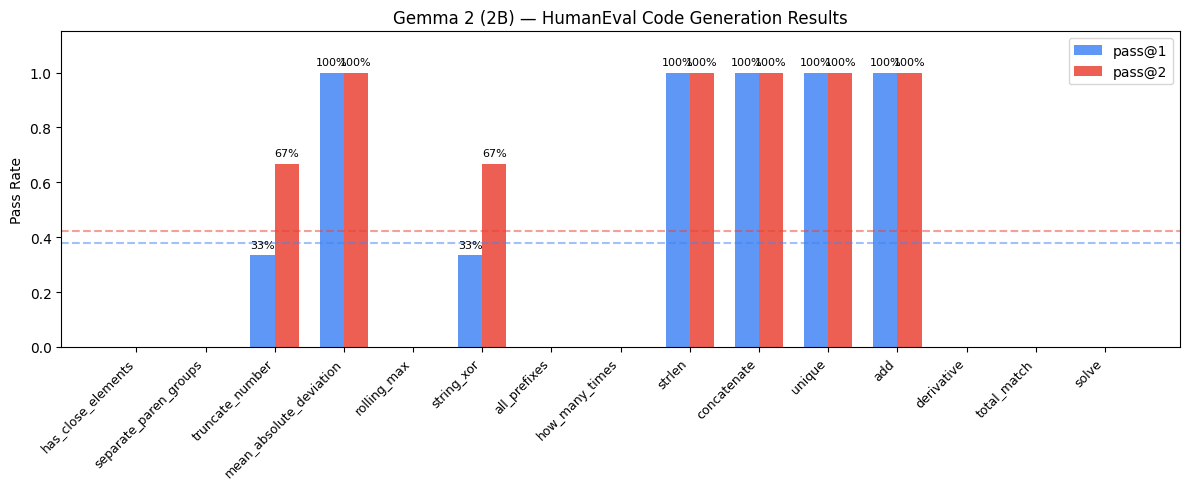


📊 Overall: pass@1 = 37.8%, pass@2 = 42.2%


In [ ]:
import matplotlib.pyplot as plt

# Extract short names for plotting
short_names = []
for problem in subset:
    short_names.append(problem["entry_point"])

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(short_names))
width = 0.35

bars1 = ax.bar(x - width/2, pass1_scores, width, label="pass@1", color="#4285F4", alpha=0.85)
bars2 = ax.bar(x + width/2, pass2_scores, width, label="pass@2", color="#EA4335", alpha=0.85)

ax.set_ylabel("Pass Rate")
ax.set_title("Gemma 2 (2B) — HumanEval Code Generation Results")
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=9)
ax.legend()
ax.set_ylim(0, 1.15)
ax.axhline(y=np.mean(pass1_scores), color="#4285F4", linestyle="--", alpha=0.5, label=f"avg pass@1")
ax.axhline(y=np.mean(pass2_scores), color="#EA4335", linestyle="--", alpha=0.5, label=f"avg pass@2")

# Add value labels on bars
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n📊 Overall: pass@1 = {np.mean(pass1_scores):.1%}, pass@2 = {np.mean(pass2_scores):.1%}")

### 🔍 Exercise: Inspect a failure

Pick a problem where the model failed and look at what it actually generated. Can you spot what went wrong?

In [ ]:
# Pick a problem that failed (modify the index to explore different ones)
failed_tasks = [task_id for task_id, results in test_results.items() if not any(results)]

if failed_tasks:
    inspect_task = failed_tasks[0]
    problem = subset.filter(lambda x: x["task_id"] == inspect_task)[0]

    print(f"Problem: {inspect_task}")
    print(f"\n{'='*60}")
    print("PROMPT:")
    print(f"{'='*60}")
    print(problem["prompt"])

    print(f"\n{'='*60}")
    print("MODEL'S COMPLETION (sample 0 — greedy):")
    print(f"{'='*60}")
    print(results[inspect_task][0])

    print(f"\n{'='*60}")
    print("EXPECTED SOLUTION:")
    print(f"{'='*60}")
    print(problem["canonical_solution"])
else:
    print("🎉 The model passed all selected problems! Try adding harder ones.")

Filter:   0%|          | 0/15 [00:00<?, ? examples/s]

Problem: HumanEval/0

PROMPT:
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)
    True
    """


MODEL'S COMPLETION (sample 0 — greedy):
    for i in range(len(numbers) - 1):
        if abs(numbers[i] - numbers[i + 1]) < threshold:
            return True
    return False


EXPECTED SOLUTION:
    for idx, elem in enumerate(numbers):
        for idx2, elem2 in enumerate(numbers):
            if idx != idx2:
                distance = abs(elem - elem2)
                if distance < threshold:
                    return True

    return False



---
## 5. Discussion & Reflection

### Key takeaways

**About the model:**
- Gemma 2 2B is a **2.6 billion parameter** model that fits on a free Colab T4 GPU
- Even at this small scale, it can solve some basic programming problems
- But it struggles with problems requiring complex reasoning or multi-step logic

**About pass@k:**
- **pass@1** measures reliability — can the model get it right on the first try?
- **pass@2** shows how much *sampling diversity* helps — sometimes the model "knows" the answer but doesn't always produce it
- The gap between pass@1 and pass@2 tells you about model uncertainty

### Discussion questions

1. **Which types of problems did the model solve vs. fail?** Is there a pattern?
2. **How does the gap between pass@1 and pass@2 relate to model confidence?**
3. **What are the limitations of HumanEval as a benchmark?** (Hint: think about problem diversity, difficulty distribution, and what "coding ability" really means)
4. **How would you expect a 7B or 70B model to perform differently?**
5. **Is pass rate the only thing that matters?** What about code quality, efficiency, or readability?

### For further exploration

- 🔗 [HumanEval Paper (Chen et al., 2021)](https://arxiv.org/abs/2107.03374) — original Codex paper introducing HumanEval
- 🔗 [Gemma 2 Technical Report](https://arxiv.org/abs/2408.00118)
- 🔗 [lm-evaluation-harness](https://github.com/EleutherAI/lm-evaluation-harness) — run many benchmarks with one tool
- 🔗 [BigCode Leaderboard](https://huggingface.co/spaces/bigcode/bigcode-models-leaderboard) — compare code models

---
## 6. Cleanup

Free GPU memory when you're done.

In [ ]:
# Free GPU memory
del model
del tokenizer
torch.cuda.empty_cache()
print("✅ GPU memory freed.")